# Hierarchical Clustering Implementation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets 

In [2]:
# Import IRIS dataset 
iris = datasets.load_iris()

In [3]:
iris_data = pd.DataFrame(iris.data)

In [6]:
iris_data.columns = iris.feature_names

In [7]:
iris_data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [26]:
# Standarddization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [27]:
X_scaled = scaler.fit_transform(iris_data)

In [28]:
# Apply the PCA
from sklearn.decomposition import PCA

In [29]:
pca = PCA(n_components = 2)

In [30]:
pca_scaled = pca.fit_transform(X_scaled)

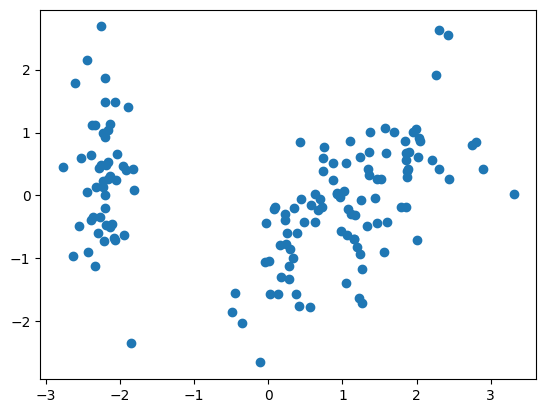

In [31]:
plt.scatter(pca_scaled[:,0], pca_scaled[:,1])

In [32]:
## Agglomerative Clustering 
## to construst a dendogram
import scipy.cluster.hierarchy as sc

Text(0, 0.5, 'Eucledian Distance')

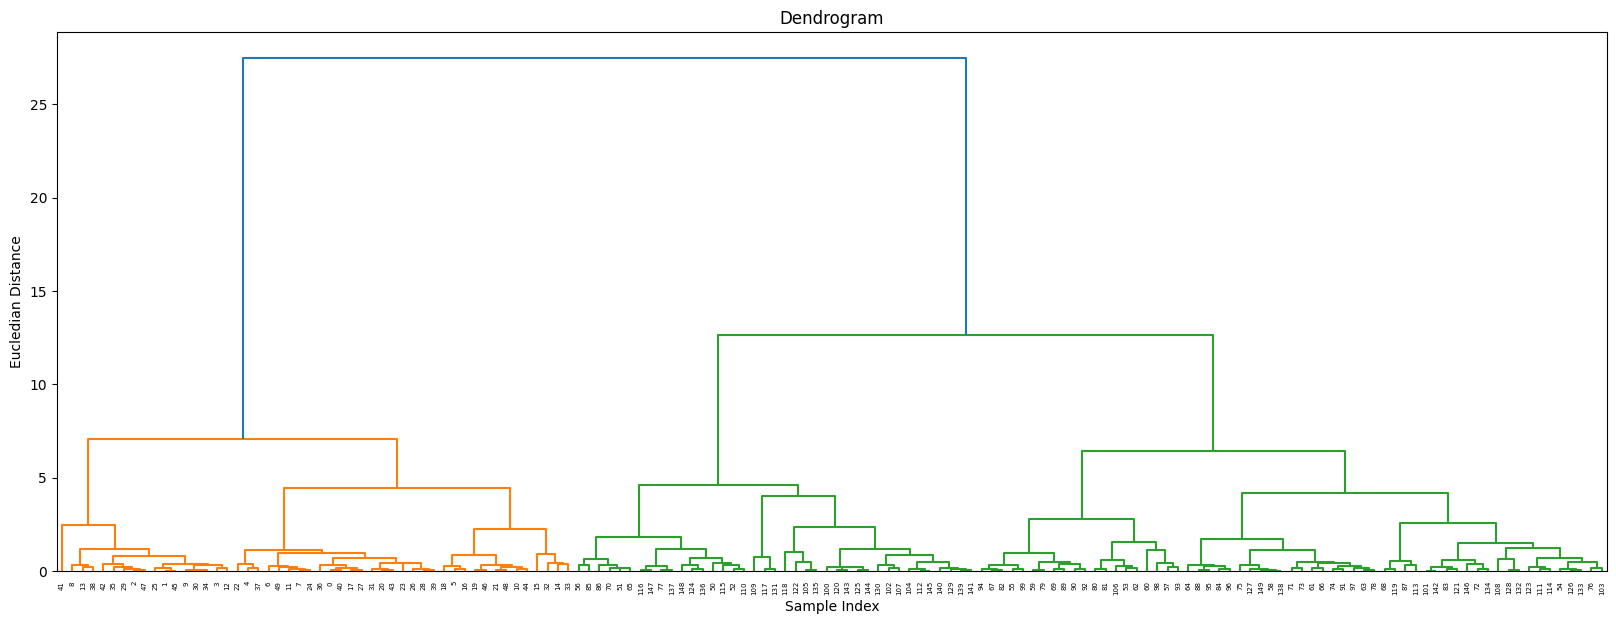

In [33]:
# plot the dendogram
plt.figure(figsize=(20, 7))
plt.title("Dendrograms")

# create Dendogram
sc.dendrogram(sc.linkage(pca_scaled,method="ward"))
plt.title("Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Eucledian Distance")

In [42]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters = 2, metric = "euclidiean", linkage="ward")


In [56]:
##  Notice youu start at 2 clusters for for silhouette coeffecient
from sklearn.metrics import silhouette_score
silhouette_coeffecients = []
for k in range(2, 11):
    agglo = AgglomerativeClustering(n_clusters=k,linkage="ward")
    agglo.fit(X_scaled)
    score = silhouette_score(X_scaled, agglo.labels_)
    silhouette_coeffecients.append(score)

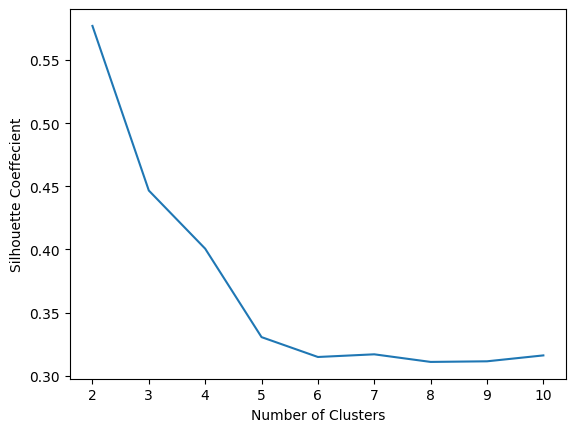

In [57]:
## plotting silhouette score
plt.plot(range(2, 11),silhouette_coeffecients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coeffecient")
plt.show()    